In [1]:
from pylib.preamble import *
enable_autoreload()

from pylib.fig_setup import PALETTE, STYLE, LW, SEC_PALETTE, style_ax, legend, country_handles

# Effect of road transport electrification on EU aggregate rate

**Scope:** `FC_TRA_ROAD_E` ("Vejtransport") covers all road transport — trucks, personal cars, buses, motorcycles. There is no further sub-split at this disaggregation level in `nrg_bal_c`. Private car fuel is counted under road transport, not under households (`FC_OTH_HH_E` captures heating, cooking, and appliances only).

**Analysis:** What is the aggregate effect on the EU electrification rate of raising road transport from its current level to 100%?

1. Today's electrification rate: road transport and aggregate
2. Road transport's share of total final energy consumption
3. Counterfactual gain: $\Delta E_{\text{agg}} = s_{\text{road}} \cdot (1 - e_{\text{road}})$

*`1. elektrificeringsrater`*

*electrification data*

In [2]:
# 1. elektrificeringsrater
df_s_ = pd.read_parquet("0_intermediate/df_s.parquet")
df_a_ = pd.read_parquet("0_intermediate/df_a.parquet")

df_s = df_s_[
    df_s_.nrg_bal.eq('FC_TRA_ROAD_E') &
    df_s_.year.eq(2023) &
    df_s_.geo.eq('EU27_2020')
][['label', 'value']]

df_a = df_a_[
    df_a_.year.eq(2023) &
    df_a_.geo.eq('EU27_2020')
][['label','value']]

*`2. energivægte`*

*energy weight data (total final consumption)*

In [3]:
# 2. energivægte
df_enw_ = fetch_energy_weights(
    sectors=['FC_TRA_ROAD_E', 'FC_E'],
    countries=['EU27_2020'],
)
df_enw = df_enw_[df_enw_.year.eq(2023)]

road_tj  = df_enw.loc[df_enw.nrg_bal.eq('FC_TRA_ROAD_E'), 'value'].values[0]
total_tj = df_enw.loc[df_enw.nrg_bal.eq('FC_E'),          'value'].values[0]
s_road   = road_tj / total_tj

print(f's_road = {s_road:.2%}')

s_road = 30.10%


*`3. kontrafaktisk beregning`*

*Beregner den hypotetiske stigning i EU's aggregerede elektrificeringsrate ved fuld elektrificering af vejtransport, med et energieffektivitetsforhold $\eta = 2$ (1 enhed el leverer samme service som 2 enheder fossil energi):*

$$\Delta E_\text{agg} = \frac{s_\text{road} \cdot (1 - e_\text{road}/100)}{\eta}$$

In [4]:
# 3. kontrafaktisk beregning
e_road = df_s['value'].values[0]   # road electrification rate (%)
e_agg  = df_a['value'].values[0]   # aggregate electrification rate (%)
eta    = 2                          # efficiency ratio: 1 unit electricity = eta units fossil service

delta_pp = s_road * (1 - e_road / 100) / eta * 100
e_cf     = e_agg + delta_pp

print("Today (EU-27, 2023)")
print(f"  Aggregate electrification rate:        {e_agg:.1f}%")
print(f"  Road transport electrification rate:    {e_road:.1f}%")
print(f"  Road share of total final energy:      {s_road:.1%}")
print()
print(f"Counterfactual: road transport electrified to 100% (η = {eta})")
print(f"  Gain:                                 +{delta_pp:.1f}pp")
print(f"  New aggregate electrification rate:    {e_cf:.1f}%")

Today (EU-27, 2023)
  Aggregate electrification rate:        22.9%
  Road transport electrification rate:    0.5%
  Road share of total final energy:      30.1%

Counterfactual: road transport electrified to 100% (η = 2)
  Gain:                                 +15.0pp
  New aggregate electrification rate:    37.9%


*`4. trucks in european countries`*

*Nul-emissionsandel af nysalg (Q3 2024 → Q3 2025) for tunge lastbiler, varebiler og busser. Kilde: Transport & Environment, Zero-Emission Truck/Van/Bus Sales Monitor Q3 2025. FI mangler Q3 2025-data.*

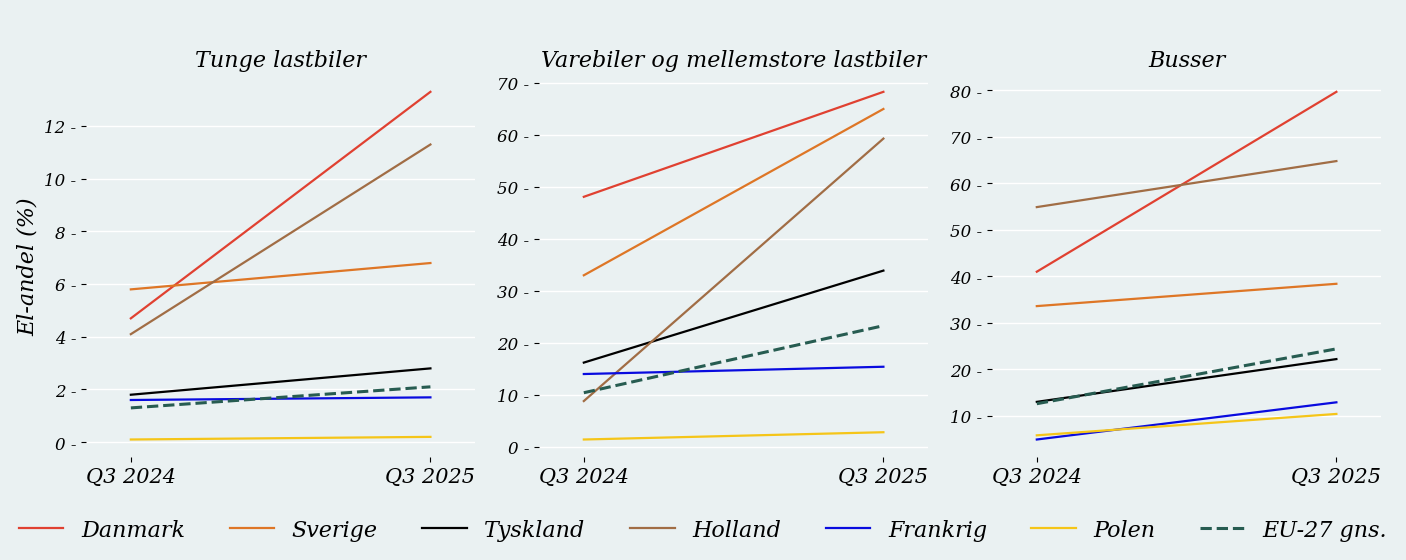

In [13]:
# 4. trucks in european countries
# Source: Transport & Environment, ZE Sales Monitor Q3 2025 (Tables 1–3)

_x       = np.array([0, 1])
_xlabels = ['Q3 2024', 'Q3 2025']
_GEOS    = ['DK', 'SE', 'DE', 'NL', 'FR', 'PL', 'EU27_2020']

_PAL   = {**PALETTE,  'PL': '#F5C518'}
_STY   = {**STYLE,    'PL': '-'}
_LW_   = {**LW,       'PL': 1.6}
_NAMES = {**var_groups.country_names, 'PL': 'Polen'}

# zero-emission share of new registrations (%), [Q3 2024, Q3 2025]
_heavy = {                         # Table 1: heavy trucks
    'DK': [ 4.7, 13.3], 'SE': [ 5.8,  6.8], 'DE': [1.8, 2.8],
    'NL': [ 4.1, 11.3], 'FR': [ 1.6,  1.7], 'PL': [0.1, 0.2],
    'EU27_2020': [1.3, 2.1],
}
_vans = {                          # Table 2: medium trucks and vans
    'DK': [48.1, 68.3], 'SE': [33.0, 65.0], 'DE': [16.2, 33.9],
    'NL': [ 8.8, 59.3], 'FR': [14.0, 15.4], 'PL': [ 1.4,  2.8],
    'EU27_2020': [10.4, 23.3],
}
_buses = {                         # Table 3: buses and coaches
    'DK': [41.0, 79.7], 'SE': [33.6, 38.4], 'DE': [13.0, 22.2],
    'NL': [54.9, 64.8], 'FR': [ 4.9, 12.9], 'PL': [ 5.8, 10.4],
    'EU27_2020': [12.6, 24.4],
}

_datasets = [_heavy,            _vans,                           _buses]
_titles   = ['Tunge lastbiler', 'Varebiler og mellemstore lastbiler', 'Busser']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, data, title in zip(axes, _datasets, _titles):
    for geo in _GEOS:
        ax.plot(_x, data[geo], color=_PAL[geo], ls=_STY[geo], lw=_LW_[geo])
    style_ax(ax, pd.Series(_x), step=1)
    ax.set_xlim(-0.15, 1.15)
    ax.set_xticks(_x)
    ax.set_xticklabels(_xlabels)
    ax.set_title(title)

axes[0].set_ylabel('El-andel (%)')

_handles = [plt.Line2D([0], [0], color=_PAL[g], ls=_STY[g], lw=_LW_[g],
                       label=_NAMES[g]) for g in _GEOS]
fig.legend(handles=_handles, loc='upper center', bbox_to_anchor=(0.5, 0),
           ncol=len(_GEOS), frameon=False, prop={'style': 'italic'})

plt.suptitle(' ')
plt.tight_layout()
plt.show()

**kilde:** https://theicct.org/publication/r2z-eu-hdv-market-development-quarterly-january-september-2025-dec25/